In [11]:
import pandas as pd
from pathlib import Path
import warnings
import os
import joblib


from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation Metrics
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')
DATA_PATH = Path('../data/student_dropout_dataset_v3.csv')
df = pd.read_csv(DATA_PATH)

# 1. Načtení dat a bezpečné úpravy

In [12]:
# 1. Parental Education
df['Parental_Education'] = df['Parental_Education'].fillna('Unknown')
education_mapping = {
    'Unknown': 0,
    'High School': 1,
    'Bachelor': 2,
    'Master': 3,
    'PhD': 4
}
df['Parental_Education'] = df['Parental_Education'].replace(education_mapping)

# df = pd.get_dummies(df, columns=['Department'], drop_first=True, dtype=int)

binary_columns = ['Internet_Access', 'Part_Time_Job', 'Scholarship']
for column in binary_columns:
    df[column] = (df[column] == 'Yes').astype(int)

gender_mapping = {
    'Female': 1,
    'Male': 0}
df['Gender'] = df['Gender'].replace(gender_mapping)

semester_mapping = {
    'Year 1': 1,
    'Year 2': 2,
    'Year 3': 3,
    'Year 4': 4
}
df['Semester'] = df['Semester'].replace(semester_mapping)

df['GPA_trend'] = df["CGPA"] - df['Semester_GPA']


# 2. Data Split

In [13]:
y = df['Dropout']
X = df.drop(columns=['Dropout'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Data Preprocessing & Feature Engineering

In [14]:
class HolmanImpute(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.stats = {}

    def fit(self, X, y=None):
        self.stats['income_medians'] = X.groupby('Parental_Education')['Family_Income'].median()
        self.stats['study_means'] = X.groupby('Parental_Education')['Study_Hours_per_Day'].mean()
        self.stats['stress_median'] = X['Stress_Index'].median()
        self.stats['age_mean'] = X['Age'].mean()
        return self

    def transform(self, X):
        X_copy = X.copy()
        X_copy['Family_Income'] = X_copy['Family_Income'].fillna(X_copy['Parental_Education'].map(self.stats['income_medians']))
        X_copy['Study_Hours_per_Day'] = X_copy['Study_Hours_per_Day'].fillna(X_copy['Parental_Education'].map(self.stats['study_means']))
        X_copy['Stress_Index'] = X_copy['Stress_Index'].fillna(self.stats['stress_median'])
        X_copy['Age_Gap'] = X_copy['Age'] - self.stats['age_mean']

        # Smazání nepotřebných (jak Matěj chtěl)
        cols_to_drop = ['Student_ID', 'Age', 'Parental_Education', 'GPA', 'Semester_GPA']
        cols_to_drop = [c for c in cols_to_drop if c in X_copy.columns]
        X_copy = X_copy.drop(columns=cols_to_drop)
        return X_copy

# 2. Sestavení finální Roury
# První krok: náš HolmanImpute (zpracuje tabulku a vyhodí věk/vzdělání)
# Druhý krok: ColumnTransformer (přeškáluje čísla a zakóduje Fakultu, zbytek nechá být)
numeric_cols = ['Family_Income', 'Study_Hours_per_Day', 'Stress_Index', 'Age_Gap', 'CGPA', 'GPA_trend']

col_transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Department'])
    ],
    remainder='passthrough', # Sloupce jako Internet_Access, Semester atd. projdou rourou beze změny
    verbose_feature_names_out=False
)

# Tohle je ta ultimátní Pipeline
preprocessor = Pipeline(steps=[
    ('imputer', HolmanImpute()),
    ('transformer', col_transformer)
])

# Chceme na výstupu zase hezký Pandas DataFrame (kvůli grafům)
col_transformer.set_output(transform="pandas")

# 3. Aplikace a EXPORT pro zbytek týmu
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# Vytvoříme složku models a rouru do ní zamrazíme
os.makedirs('../models', exist_ok=True)
joblib.dump(preprocessor, '../models/preprocessor.pkl')

['../models/preprocessor.pkl']

In [15]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ),
}
scaled_models = {'Logistic Regression'}

In [16]:
smote = SMOTE(random_state=42)
results = {}

for name, model in models.items():

    X_tr_resampled, y_train_resampled = smote.fit_resample(X_train_prep, y_train)
    model.fit(X_tr_resampled, y_train_resampled)

    y_pred = model.predict(X_test_prep)
    y_proba = model.predict_proba(X_test_prep)[:, 1]

    results[name] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'report': classification_report(y_test, y_pred),
        'y_pred': y_pred,
        'y_proba': y_proba,
    }

    print(f"{'=' * 50}")
    print(f"  {name}")
    print(f"{'=' * 50}")
    print(f"  Accuracy : {results[name]['accuracy']:.4f}")
    print(f"  ROC-AUC  : {results[name]['roc_auc']:.4f}")
    print(f"\n{results[name]['report']}")

  Logistic Regression
  Accuracy : 0.7480
  ROC-AUC  : 0.7981

              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1529
           1       0.48      0.69      0.56       471

    accuracy                           0.75      2000
   macro avg       0.68      0.73      0.69      2000
weighted avg       0.79      0.75      0.76      2000

  Random Forest
  Accuracy : 0.7795
  ROC-AUC  : 0.7972

              precision    recall  f1-score   support

           0       0.87      0.84      0.85      1529
           1       0.53      0.59      0.56       471

    accuracy                           0.78      2000
   macro avg       0.70      0.71      0.71      2000
weighted avg       0.79      0.78      0.78      2000

  Gradient Boosting
  Accuracy : 0.7920
  ROC-AUC  : 0.8009

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1529
           1       0.57      0.49      0.53       471

 

In [17]:
cols_to_drop_gpa = ['CGPA', 'GPA_trend']
X_train_wo_gpa = X_train_prep.drop(columns=cols_to_drop_gpa, errors='ignore')
X_test_wo_gpa = X_test_prep.drop(columns=cols_to_drop_gpa, errors='ignore')

results_wo_gpa = {}

for name, model in models.items():
    X_tr_resampled, y_train_resampled = smote.fit_resample(X_train_wo_gpa, y_train)

    model.fit(X_tr_resampled, y_train_resampled)

    y_pred = model.predict(X_test_wo_gpa)
    y_proba = model.predict_proba(X_test_wo_gpa)[:, 1]

    results_wo_gpa[name] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'report': classification_report(y_test, y_pred),
    }

    print(f"\n{'=' * 50}")
    print(f"  {name} (Bez GPA)")
    print(f"{'=' * 50}")
    print(f"  Accuracy : {results_wo_gpa[name]['accuracy']:.4f}")
    print(f"  ROC-AUC  : {results_wo_gpa[name]['roc_auc']:.4f}")
    print(f"\n{results_wo_gpa[name]['report']}")


  Logistic Regression (Bez GPA)
  Accuracy : 0.6640
  ROC-AUC  : 0.6908

              precision    recall  f1-score   support

           0       0.84      0.69      0.76      1529
           1       0.36      0.58      0.45       471

    accuracy                           0.66      2000
   macro avg       0.60      0.63      0.60      2000
weighted avg       0.73      0.66      0.69      2000


  Random Forest (Bez GPA)
  Accuracy : 0.7585
  ROC-AUC  : 0.6919

              precision    recall  f1-score   support

           0       0.80      0.91      0.85      1529
           1       0.48      0.28      0.36       471

    accuracy                           0.76      2000
   macro avg       0.64      0.59      0.60      2000
weighted avg       0.73      0.76      0.73      2000


  Gradient Boosting (Bez GPA)
  Accuracy : 0.7780
  ROC-AUC  : 0.7033

              precision    recall  f1-score   support

           0       0.80      0.95      0.87      1529
           1       0.58

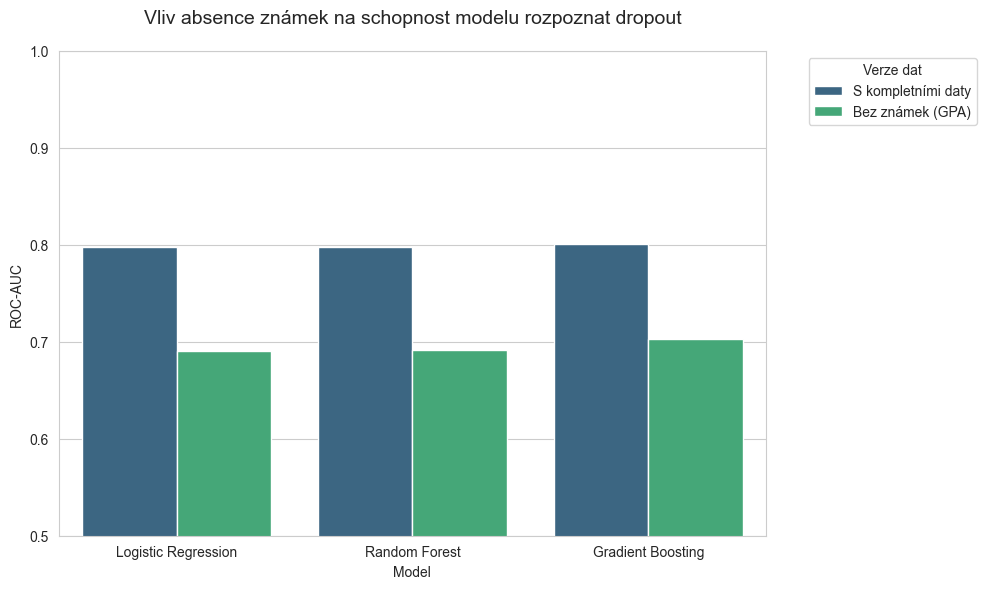

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = []
for model_name in results.keys():
    plot_data.append({'Model': model_name, 'ROC-AUC': results[model_name]['roc_auc'], 'Typ': 'S kompletními daty'})
    if model_name in results_wo_gpa:
        plot_data.append({'Model': model_name, 'ROC-AUC': results_wo_gpa[model_name]['roc_auc'], 'Typ': 'Bez známek (GPA)'})

df_plot = pd.DataFrame(plot_data)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.barplot(data=df_plot, x='Model', y='ROC-AUC', hue='Typ', palette='viridis')

plt.title('Vliv absence známek na schopnost modelu rozpoznat dropout', fontsize=14, pad=20)
plt.ylim(0.5, 1.0)
plt.ylabel('ROC-AUC')
plt.legend(title='Verze dat', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

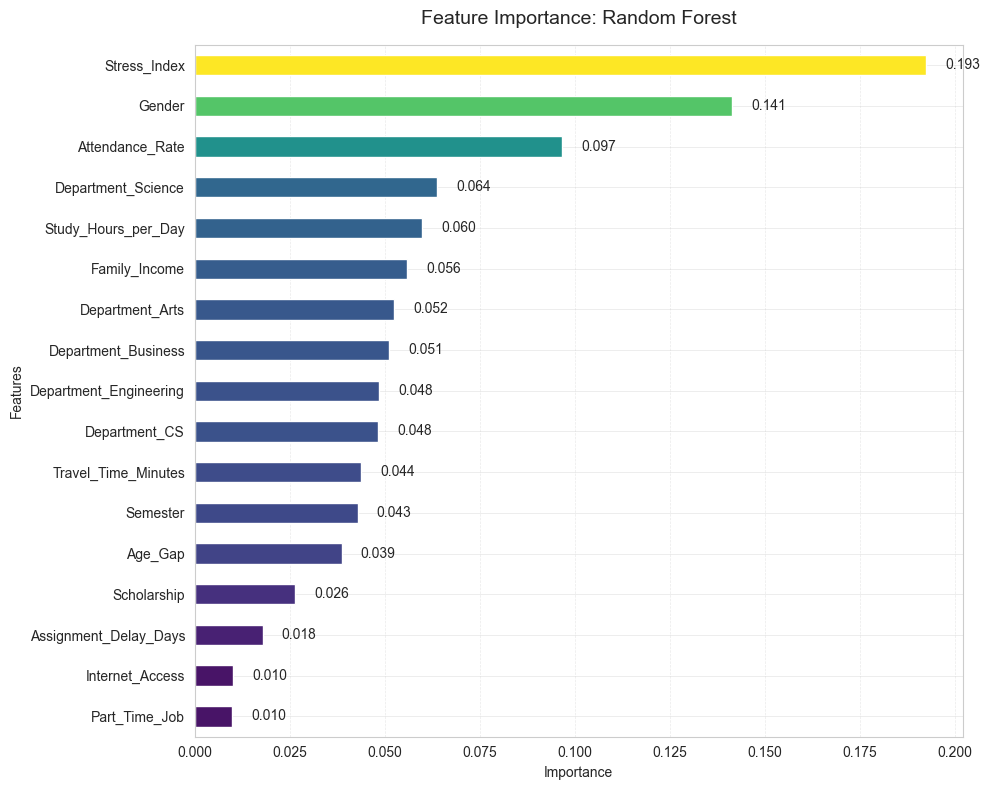

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

target_results = results
model_name = 'Random Forest'
best_model = target_results[model_name]['model']

importances = best_model.feature_importances_

if len(importances) == len(X_train_prep.columns):
    features = X_train_prep.columns
else:
    features = X_train_wo_gpa.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
colors = plt.cm.viridis(feat_imp.values / max(feat_imp.values))
feat_imp.plot(kind='barh', color=colors)

plt.title(f'Feature Importance: {model_name}', fontsize=14, pad=15)
plt.xlabel('Importance')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.4)

for i, v in enumerate(feat_imp.values):
    plt.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

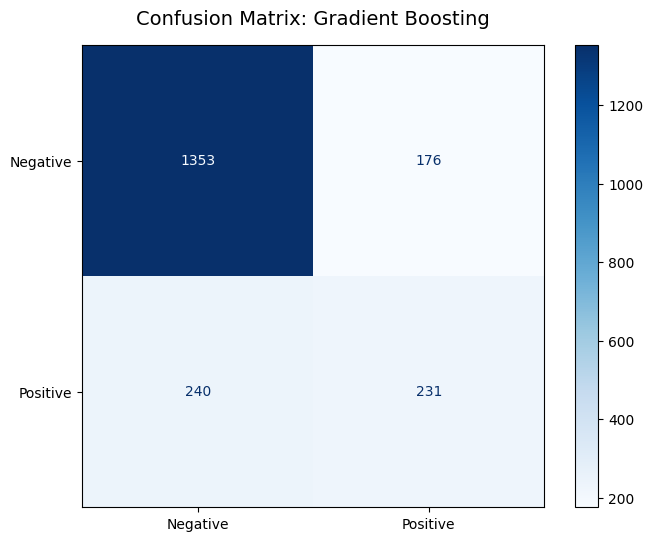

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.style.use('default')
plt.rcParams.update({
    'text.color': "black",
    'axes.labelcolor': "black",
    'xtick.color': "black",
    'ytick.color': "black",
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

model_name = 'Gradient Boosting'
y_pred_gb = results[model_name]['y_pred']
cm = confusion_matrix(y_test, y_pred_gb)

fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues', ax=ax, values_format='d')

ax.set_xlabel('')
ax.set_ylabel('')

plt.title(f'Confusion Matrix: {model_name}', fontsize=14, pad=15, color='black')
plt.grid(False)
plt.show()